100%|██████████| 170M/170M [00:13<00:00, 12.6MB/s]


Class distribution:
Class 0: 5000
Class 1: 5000
Class 2: 5000
Class 3: 5000
Class 4: 5000
Class 5: 5000
Class 6: 5000
Class 7: 5000
Class 8: 5000
Class 9: 5000
Epoch 1
Train Acc: 28.52% | Test Acc: 41.14%
-------------------
Epoch 2
Train Acc: 44.36% | Test Acc: 47.63%
-------------------
Epoch 3
Train Acc: 52.19% | Test Acc: 61.95%
-------------------
Epoch 4
Train Acc: 57.25% | Test Acc: 64.14%
-------------------
Epoch 5
Train Acc: 60.74% | Test Acc: 68.61%
-------------------
Epoch 6
Train Acc: 63.49% | Test Acc: 71.12%
-------------------
Epoch 7
Train Acc: 65.94% | Test Acc: 68.39%
-------------------
Epoch 8
Train Acc: 67.87% | Test Acc: 76.68%
-------------------
Epoch 9
Train Acc: 69.71% | Test Acc: 73.24%
-------------------
Epoch 10
Train Acc: 71.35% | Test Acc: 77.26%
-------------------
Epoch 11
Train Acc: 73.06% | Test Acc: 79.50%
-------------------
Epoch 12
Train Acc: 74.76% | Test Acc: 81.39%
-------------------
Epoch 13
Train Acc: 76.10% | Test Acc: 80.29%
-----------

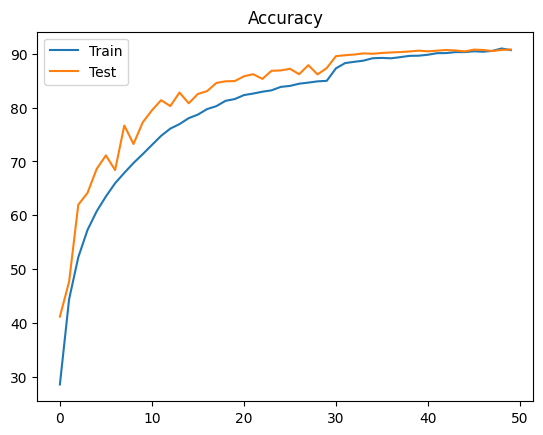

Best Accuracy: 90.82


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==============================
# 1. DATA AUGMENTATION
# ==============================

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])


# ==============================
# 2. LOAD DATA
# ==============================

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=128, shuffle=True)

test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=128, shuffle=False)


# ==============================
# 3. PHÂN TÍCH DỮ LIỆU
# ==============================

targets = train_dataset.targets
unique, counts = np.unique(targets, return_counts=True)

print("Class distribution:")
for u, c in zip(unique, counts):
    print(f"Class {u}: {c}")

# CIFAR-10 đã cân bằng → không cần oversampling


# ==============================
# 4. CNN MODEL (DEEP CNN)
# ==============================

class CIFAR_CNN(nn.Module):

    def __init__(self):
        super(CIFAR_CNN, self).__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(3,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            # Block 2
            nn.Conv2d(64,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),

            # Block 3
            nn.Conv2d(128,256,3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256,256,3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.4)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*4*4,512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512,10)
        )

    def forward(self,x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = CIFAR_CNN().to(device)


# ==============================
# 5. LOSS + OPTIMIZER
# ==============================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer, step_size=30, gamma=0.1
)


# ==============================
# 6. TRAINING
# ==============================

num_epochs = 50

train_acc_list = []
test_acc_list = []

best_acc = 0

for epoch in range(num_epochs):

    # TRAIN
    model.train()
    correct = 0
    total = 0

    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs,1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total
    train_acc_list.append(train_acc)

    # TEST
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_acc = 100 * correct / total
    test_acc_list.append(test_acc)

    scheduler.step()

    print(f"Epoch {epoch+1}")
    print(f"Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")
    print("-------------------")

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), "best_cifar10_model.pth")


# ==============================
# 7. PLOT
# ==============================

plt.plot(train_acc_list, label="Train")
plt.plot(test_acc_list, label="Test")
plt.legend()
plt.title("Accuracy")
plt.show()

print("Best Accuracy:", best_acc)